In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import PIL

2026-02-09 12:43:26.213402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770641006.383895      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770641006.439214      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770641006.832492      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641006.832529      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641006.832532      55 computation_placer.cc:177] computation placer alr

In [2]:
file_path = r"/kaggle/input/plantvillage-dataset/color"

IMAGE_SIZE = (224,224)
BATCH_SIZE = 16
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = file_path,
    validation_split = 0.3,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED,
    subset ="training"
    
) 

temp_ds = tf.keras.utils.image_dataset_from_directory(
    directory = file_path,
    validation_split = 0.3,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED,
    subset ="validation"
    
)


val_ds = temp_ds.take(int(0.5 * len(temp_ds)))
test_ds = temp_ds.skip(int(0.5 * len(temp_ds)))

Found 54305 files belonging to 38 classes.
Using 38014 files for training.


2026-02-09 12:38:29.722279: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 54305 files belonging to 38 classes.
Using 16291 files for validation.


In [3]:
train_ds = train_ds.shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(1000).prefetch(tf.data.AUTOTUNE)

In [2]:
import cv2

In [30]:
image_path = r"/kaggle/input/plantvillage-dataset/segmented/Apple___Black_rot/02186b4f-a9e1-4d19-ae3d-6cfb0f4b106a___JR_FrgE.S 2828_final_masked.jpg"

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

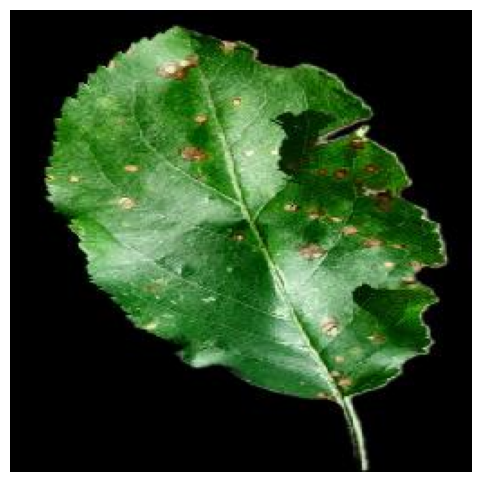

In [31]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_path)

# OpenCV → RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')

In [32]:
img = cv2.resize(img,(224,224))

In [33]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Any non-dark pixel belongs to leaf
_, leaf_mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)


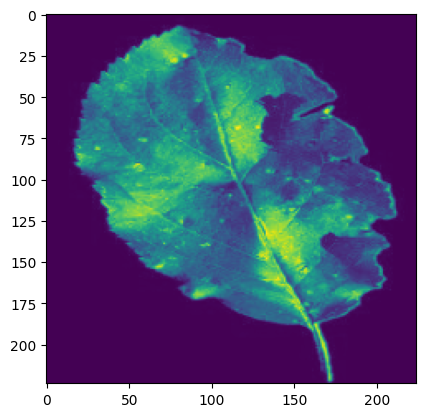

In [34]:
plt.imshow(gray)

In [35]:
import numpy as np
import pandas as pd

In [36]:
kernel = np.ones((5,5), np.uint8)
leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel)


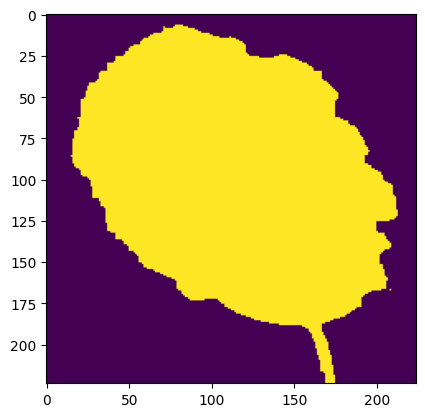

In [37]:
plt.imshow(leaf_mask)

In [40]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Healthy green range
lower_green = np.array([25, 40, 40])
upper_green = np.array([90, 255, 255])

healthy_mask = cv2.inRange(hsv, lower_green, upper_green)

# Diseased = leaf - healthy
infected_mask = cv2.bitwise_and(leaf_mask, cv2.bitwise_not(healthy_mask))


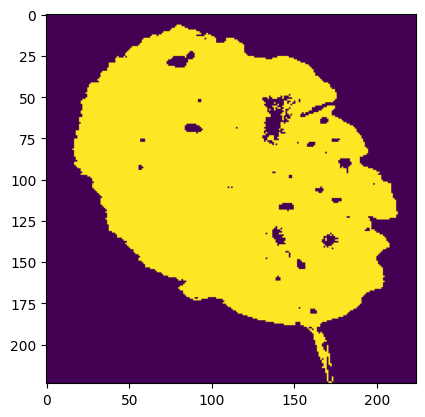

In [41]:
plt.imshow(healthy_mask)

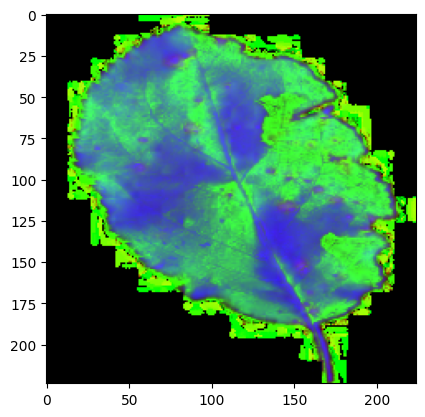

In [42]:
plt.imshow(hsv)

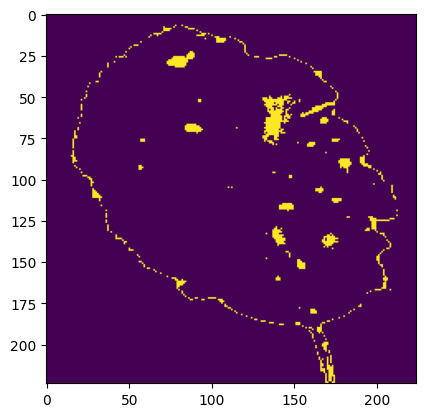

In [50]:
plt.imshow(infected_mask)

In [53]:
leaf_pixels = np.sum(leaf_mask > 0)
infected_pixels = np.sum(infected_mask > 0)

infection_percent = (infected_pixels / leaf_pixels) * 100
infection_percent

np.float64(5.6821766561514195)

In [52]:
if infection_percent < 15:
    severity = "Mild"
elif infection_percent < 40:
    severity = "Moderate"
else:
    severity = "Severe"


In [73]:
import cv2
import cv2
import numpy as np
import os
import csv

DATASET_PATH = "/kaggle/input/plantvillage-dataset/segmented"
OUTPUT_CSV = "severity_labels.csv"

def calculate_severity(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None ,None, None

    img = cv2.resize(img, (224, 224))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # --- Healthy Leaf (Green) Mask ---
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    healthy_mask = cv2.inRange(hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)
    healthy_mask = cv2.morphologyEx(healthy_mask, cv2.MORPH_OPEN, kernel)
    healthy_mask = cv2.morphologyEx(healthy_mask, cv2.MORPH_CLOSE, kernel)

    # --- Leaf Area (everything except background) ---
    leaf_mask = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, leaf_mask = cv2.threshold(leaf_mask, 10, 255, cv2.THRESH_BINARY)

    # --- Infected = Leaf - Healthy ---
    infected_mask = cv2.subtract(leaf_mask, healthy_mask)
    infected_mask = cv2.morphologyEx(infected_mask, cv2.MORPH_OPEN, kernel)

    leaf_pixels = np.sum(leaf_mask > 0)
    infected_pixels = np.sum(infected_mask > 0)

    if leaf_pixels == 0:
        return None, None ,None , None

    infection_percent = (infected_pixels / leaf_pixels) * 100

    # --- Severity ---
    if infection_percent < 15:
        severity = "Mild"
    elif infection_percent < 40:
        severity = "Moderate"
    else:
        severity = "Severe"

    return infection_percent, severity , infected_pixels , leaf_pixels


In [74]:
with open(OUTPUT_CSV, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["image_path", "disease_label", "infection_percent",'infected_pixels','leaf_pixels',"severity"])

    for disease_folder in os.listdir(DATASET_PATH):
        folder_path = os.path.join(DATASET_PATH, disease_folder)

        if not os.path.isdir(folder_path):
            continue

        print(f"Processing: {disease_folder}")

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)

            infection_percent, severity ,infected_pixels , leaf_pixels = calculate_severity(img_path)

            if severity is not None:
                writer.writerow([
                    img_path,
                    disease_folder,
                    round(infection_percent, 2),
                    infected_pixels,
                    leaf_pixels,
                    severity
                ])

print("✅ Severity labels generated successfully!")


Processing: Tomato___Late_blight
Processing: Tomato___healthy
Processing: Grape___healthy
Processing: Orange___Haunglongbing_(Citrus_greening)
Processing: Soybean___healthy
Processing: Squash___Powdery_mildew
Processing: Potato___healthy
Processing: Corn_(maize)___Northern_Leaf_Blight
Processing: Tomato___Early_blight
Processing: Tomato___Septoria_leaf_spot
Processing: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Processing: Strawberry___Leaf_scorch
Processing: Peach___healthy
Processing: Apple___Apple_scab
Processing: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Processing: Tomato___Bacterial_spot
Processing: Apple___Black_rot
Processing: Blueberry___healthy
Processing: Cherry_(including_sour)___Powdery_mildew
Processing: Peach___Bacterial_spot
Processing: Apple___Cedar_apple_rust
Processing: Tomato___Target_Spot
Processing: Pepper,_bell___healthy
Processing: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Processing: Potato___Late_blight
Processing: Tomato___Tomato_mosaic_virus
Processing

In [56]:
import pandas as pd
import numpy as np

In [57]:
csv_path = r"/kaggle/input/severity-dataset/severity_labels.csv"
df = pd.read_csv(csv_path)

In [58]:
df.sample(10)

,image_path,disease_label,infection_percent,infected_pixels,leaf_pixels,severity
24178,/kaggle/input/plantvillage-dataset/segmented/T...,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.61,90,14794,Mild
50135,/kaggle/input/plantvillage-dataset/segmented/T...,Tomato___Leaf_Mold,12.60,1622,12876,Mild
17204,/kaggle/input/plantvillage-dataset/segmented/C...,Corn_(maize)___Northern_Leaf_Blight,4.05,1654,40881,Mild
54126,/kaggle/input/plantvillage-dataset/segmented/C...,Corn_(maize)___healthy,4.00,2008,50176,Mild
20523,/kaggle/input/plantvillage-dataset/segmented/C...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,91.96,46138,50171,Severe
32459,/kaggle/input/plantvillage-dataset/segmented/B...,Blueberry___healthy,0.00,0,19476,Mild
33645,/kaggle/input/plantvillage-dataset/segmented/P...,Peach___Bacterial_spot,13.72,2207,16082,Mild
2198,/kaggle/input/plantvillage-dataset/segmented/T...,Tomato___healthy,5.44,1138,20908,Mild
12713,/kaggle/input/plantvillage-dataset/segmented/S...,Soybean___healthy,0.00,0,24912,Mild
51584,/kaggle/input/plantvillage-dataset/segmented/T...,Tomato___Spider_mites Two-spotted_spider_mite,0.37,50,13381,Mild


In [59]:
df = df[df['infected_pixels'] > 0]


In [60]:
df_valid = df[
    (df['infected_pixels'] > 0) &
    (~df['disease_label'].str.contains('healthy', case=False))
]

p45 = np.percentile(df_valid['infection_percent'], 40)
p60 = np.percentile(df_valid['infection_percent'],50 )

print(p45, p60)


1.74 2.76


In [61]:
def asign_severity(x):
    if x<p45:
        return "Mild"
    elif x<60:
        return "Moderate"

    else:
        return "Severe"



In [63]:
df['severity'] = df["infection_percent"].apply(asign_severity)

In [64]:
df['severity'].value_counts()

severity
Moderate    20872
Mild        16063
Severe        694
Name: count, dtype: int64

In [65]:
severity_map = {
    "Mild": 0,
    "Moderate": 1,
    "Severe": 2
}

df["severity_label"] = df["severity"].map(severity_map)


In [66]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["severity_label"], random_state=42)


In [67]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="severity_label",
    target_size=IMG_SIZE,
    class_mode="raw",
    batch_size=BATCH_SIZE
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="severity_label",
    target_size=IMG_SIZE,
    class_mode="raw",
    batch_size=BATCH_SIZE
)


Found 30103 validated image filenames.
Found 7526 validated image filenames.


In [68]:
from tensorflow.keras.applications import MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze base

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation="softmax")  # 3 severity classes
])


In [69]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 332s 344ms/step - accuracy: 0.6871 - loss: 0.6364 - val_accuracy: 0.7602 - val_loss: 0.5078
Epoch 2/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 328s 348ms/step - accuracy: 0.7458 - loss: 0.5194 - val_accuracy: 0.7534 - val_loss: 0.5087
Epoch 3/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 315s 335ms/step - accuracy: 0.7574 - loss: 0.4967 - val_accuracy: 0.7719 - val_loss: 0.4788
Epoch 4/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 315s 335ms/step - accuracy: 0.7647 - loss: 0.4841 - val_accuracy: 0.7802 - val_loss: 0.4744
Epoch 5/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 315s 335ms/step - accuracy: 0.7713 - loss: 0.4795 - val_accuracy: 0.7836 - val_loss: 0.4706
Epoch 6/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 319s 339ms/step - accuracy: 0.7750 - loss: 0.4658 - val_accuracy: 0.7624 - val_loss: 0.4933
Epoch 7/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 310s 330ms/step - accuracy: 0.7795 - loss: 0.4639 - val_accuracy: 0.7865 - val_loss: 0.4663
Epoch 8/10
941/941 ━━━━━━━━━━━━━━━━━━━━ 310s 330ms/step - accuracy: 0.7824 -

In [ ]:
model.evaluate(val_generator)